In [1]:
%pip install --upgrade --quiet torch pandas numpy matplotlib scikit-learn seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from datetime import datetime
import seaborn as sns


### Data Preparation

In [3]:
data = pd.read_csv('rnn_data.csv')

In [4]:
data.head()

,pitch_type,game_date,batter,pitcher,description,zone,stand,p_throws,balls,strikes,...,prev_pitch_type,seq_len,is_swing,is_whiff,is_called_strike,is_ball,in_zone,out_zone,count_state,score_diff_bat
0,FF,2025-03-18,660271,684007,called_strike,12.0,L,L,0,0,...,START,3,False,False,True,False,False,True,0-0,0
1,SL,2025-03-18,660271,684007,ball,13.0,L,L,0,1,...,FF,3,False,False,False,True,False,True,0-1,0
2,FF,2025-03-18,660271,684007,hit_into_play,5.0,L,L,1,1,...,SL,3,True,False,False,False,True,False,1-1,0
3,FS,2025-03-18,669242,684007,ball,13.0,R,L,0,0,...,START,3,False,False,False,True,False,True,0-0,0
4,FS,2025-03-18,669242,684007,swinging_strike,14.0,R,L,1,0,...,FS,3,True,True,False,False,False,True,1-0,0


In [5]:
data["is_real_pitch"] =  data["pitch_type"].notna() & (data["pitch_type"] != "ABS")

data["target_is_real_pitch"] = data.groupby("pa_id")["is_real_pitch"].shift(-1)

data["y_next_pitch_type"] = data.groupby("pa_id")["pitch_type"].shift(-1)

data_train = data[data["target_is_real_pitch"] == True].copy() 

In [6]:
# randomly select plate appearances to be a part of training and test sets

def split_by_pa_id(df: pd.DataFrame, pa_col="pa_id", ratios=(0.8, 0.2), seed: int=42):
    r_train, r_test = ratios
    assert abs((r_train + r_test) - 1.0) < 1e-9

    pa_ids = df[pa_col].dropna().unique()

    rng = np.random.default_rng(seed)
    rng.shuffle(pa_ids)

    n = len(pa_ids)
    n_train = int(n*r_train)

    train_ids = set(pa_ids[:n_train])
    test_ids = set(pa_ids[n_train:])

    train_df = df[df[pa_col].isin(train_ids)].copy()
    test_df = df[df[pa_col].isin(test_ids)].copy()

    return train_df, test_df, train_ids, test_ids

In [7]:
train_df, test_df, train_ids, test_ids = split_by_pa_id(
    data_train, pa_col="pa_id", ratios=(0.8, 0.2), seed=7
)

/tmp/ipykernel_18626/1463695035.py:10: UserWarning: you are shuffling a 'StringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(pa_ids)


In [8]:
# Features to be used by the model
FEATURE_SPEC = {
    "target": "y_next_pitch_type",
    "cat_cols": [
        "pitcher", "batter", "stand", "p_throws", "inning_topbot",
        "count_state", "prev_pitch_type"
    ],
    "num_cols": [
        "balls", "strikes", "outs_when_up", "inning", "score_diff_bat",
        "on_1b", "on_2b", "on_3b"
    ],
}

TARGET_COL = FEATURE_SPEC["target"]
CAT_COLS = FEATURE_SPEC["cat_cols"]
NUM_COLS = FEATURE_SPEC["num_cols"]

### RNN Setup

In [9]:
PAD_ID = 0

def build_vocab(values):
    uniq = pd.Series(values.dropna().unique())
    return {v: i for i, v in enumerate(uniq, start=1)}

def encode(series, vocab):
    return series.map(vocab).fillna(PAD_ID).astype(int)

cat_vocabs = {c: build_vocab(train_df[c]) for c in CAT_COLS}
y_vocab    = build_vocab(train_df[TARGET_COL])

def encode_df(df):
    out = df.copy()
    for c in CAT_COLS:
        out[c + "_id"] = encode(out[c], cat_vocabs[c])
    out["y_id"] = encode(out[TARGET_COL], y_vocab)
    for c in NUM_COLS:
        out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0).astype(np.float32)
    return out

train_enc = encode_df(train_df)
test_enc  = encode_df(test_df)

In [10]:
# make all pitch sequences the same length
def make_fixed_sequences(df, pa_col="pa_id", max_len=8):
    X_cat, X_num, Y = [], [], []

    for _, g in df.groupby(pa_col, sort=False):

        cat = g[[c + "_id" for c in CAT_COLS]].to_numpy(np.int64)     
        num = g[NUM_COLS].to_numpy(np.float32)                        
        y   = g["y_id"].to_numpy(np.int64)                            

        L = min(len(g), max_len)
        cat, num, y = cat[:L], num[:L], y[:L]

        pad = max_len - L
        if pad > 0:
            cat = np.pad(cat, ((0,pad),(0,0)), constant_values=PAD_ID)
            num = np.pad(num, ((0,pad),(0,0)), constant_values=0.0)
            y   = np.pad(y,   (0,pad),         constant_values=PAD_ID)

        X_cat.append(cat); X_num.append(num); Y.append(y)

    return (
        torch.tensor(np.stack(X_cat), dtype=torch.long),
        torch.tensor(np.stack(X_num), dtype=torch.float32),
        torch.tensor(np.stack(Y),     dtype=torch.long),
    )

MAX_LEN = 8
Xc_tr, Xn_tr, Y_tr = make_fixed_sequences(train_enc, max_len=MAX_LEN)
Xc_te, Xn_te, Y_te = make_fixed_sequences(test_enc,  max_len=MAX_LEN)

In [11]:
# Create the Dataset
class PitchSeqDS(Dataset):
    def __init__(self, Xc, Xn, Y):
        self.Xc, self.Xn, self.Y = Xc, Xn, Y
    def __len__(self): return self.Y.size(0)
    def __getitem__(self, i): return self.Xc[i], self.Xn[i], self.Y[i]

train_loader = DataLoader(PitchSeqDS(Xc_tr, Xn_tr, Y_tr), batch_size=64, shuffle=True)
test_loader  = DataLoader(PitchSeqDS(Xc_te, Xn_te, Y_te), batch_size=64, shuffle=False)

In [12]:
# Model Creation
class SimplePitchRNN(nn.Module):
    def __init__(self, cat_vocab_sizes, num_features, emb_dim=16, hidden=128, num_classes=16, pad_id=0):
        super().__init__()
        self.cat_cols = list(cat_vocab_sizes.keys())

        self.embs = nn.ModuleDict({
            col: nn.Embedding(cat_vocab_sizes[col], emb_dim, padding_idx=pad_id)
            for col in self.cat_cols
        })
        
        in_dim = len(self.cat_cols) * emb_dim + num_features
        self.rnn = nn.RNN(in_dim, hidden, batch_first=True)
        self.fc  = nn.Linear(hidden, num_classes)

    def forward(self, x_cat, x_num):
        embs = []
        for j, col in enumerate(self.cat_cols):
            embs.append(self.embs[col](x_cat[:, :, j]))  
        x = torch.cat(embs + [x_num], dim=-1)           
        h, _ = self.rnn(x)                               
        return self.fc(h)                                

cat_vocab_sizes = {c: len(cat_vocabs[c]) + 1 for c in CAT_COLS}  
num_classes = len(y_vocab) + 1                                   

# Model Initialization
model = SimplePitchRNN(cat_vocab_sizes, num_features=len(NUM_COLS), num_classes=num_classes)

In [13]:
from datetime import datetime
from pathlib import Path
import pandas as pd

# Export vocabularies and feature lists with a date-stamped filename.
today = datetime.now().strftime("%Y%m%d")
repo_root = Path.cwd().parent
vocab_dir = repo_root / "model_shared" / "vocab"
feature_dir = repo_root / "model_shared" / "feature-list"
vocab_dir.mkdir(parents=True, exist_ok=True)
feature_dir.mkdir(parents=True, exist_ok=True)

rows = []
for feature, vocab in cat_vocabs.items():
    for value, idx in vocab.items():
        rows.append({"feature": feature, "value": value, "id": idx, "kind": "categorical"})
for value, idx in y_vocab.items():
    rows.append({"feature": TARGET_COL, "value": value, "id": idx, "kind": "target"})

vocab_path = vocab_dir / f"rnn_vocab_{today}.csv"
pd.DataFrame(rows).to_csv(vocab_path, index=False)

feature_rows = []
for c in CAT_COLS:
    feature_rows.append({"feature": c, "kind": "categorical"})
for c in NUM_COLS:
    feature_rows.append({"feature": c, "kind": "numerical"})
feature_rows.append({"feature": TARGET_COL, "kind": "target"})

feature_path = feature_dir / f"rnn_vocab_{today}.csv"
pd.DataFrame(feature_rows).to_csv(feature_path, index=False)

print(f"Wrote vocab to {vocab_path}")
print(f"Wrote feature list to {feature_path}")


Wrote vocab to /home/shakotan/git-linux/pitchcraft-repos/pitchcraft-model/model_shared/vocab/rnn_vocab_20260222.csv
Wrote feature list to /home/shakotan/git-linux/pitchcraft-repos/pitchcraft-model/model_shared/feature-list/rnn_vocab_20260222.csv


### Training and Evaluation

In [14]:
# Simplified the training loop
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for x_cat, x_num, y in train_loader:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y     = y.to(device)
        logits = model(x_cat, x_num)  

        loss = criterion(
            logits.reshape(-1, num_classes),
            y.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

Epoch [1/20], Loss: 1.6814
Epoch [2/20], Loss: 1.4527
Epoch [3/20], Loss: 1.3665
Epoch [4/20], Loss: 1.3263
Epoch [5/20], Loss: 1.3024
Epoch [6/20], Loss: 1.2869
Epoch [7/20], Loss: 1.2748
Epoch [8/20], Loss: 1.2656
Epoch [9/20], Loss: 1.2584
Epoch [10/20], Loss: 1.2522
Epoch [11/20], Loss: 1.2466
Epoch [12/20], Loss: 1.2420
Epoch [13/20], Loss: 1.2371
Epoch [14/20], Loss: 1.2332
Epoch [15/20], Loss: 1.2294
Epoch [16/20], Loss: 1.2260
Epoch [17/20], Loss: 1.2224
Epoch [18/20], Loss: 1.2192
Epoch [19/20], Loss: 1.2164
Epoch [20/20], Loss: 1.2135


In [ ]:
out_dir = Path.cwd() / ".." / "model_shared" / "trained-parameters"
out_dir.mkdir(parents=True, exist_ok=True)
filename = f"simple_rnn_v0_1_{datetime.now().strftime('%Y%m%d')}.pt"
save_path = out_dir / filename
torch.save(model.state_dict(), save_path)
print(f"Wrote model parameters to {save_path}")

Wrote model parameters to /home/shakotan/git-linux/pitchcraft-repos/pitchcraft-model/model-training-notebooks/trained-parameters/simple_rnn_v0_1_20260222.pt


In [16]:
PAD_ID = 0

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_cat, x_num, y in test_loader:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y     = y.to(device)

        outputs = model(x_cat, x_num)      
        predicted = outputs.argmax(dim=-1) 

        mask = (y != PAD_ID)
        correct += ((predicted == y) & mask).sum().item()
        total += mask.sum().item()

accuracy = 100 * correct / total
print(f"Token Accuracy (no PAD): {accuracy:.2f}%")


Token Accuracy (no PAD): 43.32%


In [17]:
from collections import Counter

model.eval()
counts = Counter()

with torch.no_grad():
    for x_cat, x_num, y in test_loader:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)

        preds = model(x_cat, x_num).argmax(dim=-1)
        for p in preds.view(-1).tolist():
            if p != 0:
                counts[p] += 1

print(counts.most_common(5))


[(2, 108775), (4, 55278), (1, 35030), (8, 25418), (9, 10960)]


In [18]:
# reverse vocab
id_to_pitch = {v: k for k, v in y_vocab.items()}

for pid, cnt in counts.most_common(5):
    print(id_to_pitch.get(pid, "PAD"), cnt)


FF 108775
SI 55278
SL 35030
FC 25418
CH 10960


In [19]:
model.eval()
correct = 0
total = 0
K = 3

with torch.no_grad():
    for x_cat, x_num, y in test_loader:
        x_cat, x_num, y = x_cat.to(device), x_num.to(device), y.to(device)
        logits = model(x_cat, x_num)
        topk = logits.topk(K, dim=-1).indices 

        mask = (y != PAD_ID)
        match = (topk == y.unsqueeze(-1)).any(dim=-1)

        correct += (match & mask).sum().item()
        total += mask.sum().item()

print(f"Top-{K} Accuracy: {100*correct/total:.2f}%")


Top-3 Accuracy: 87.81%


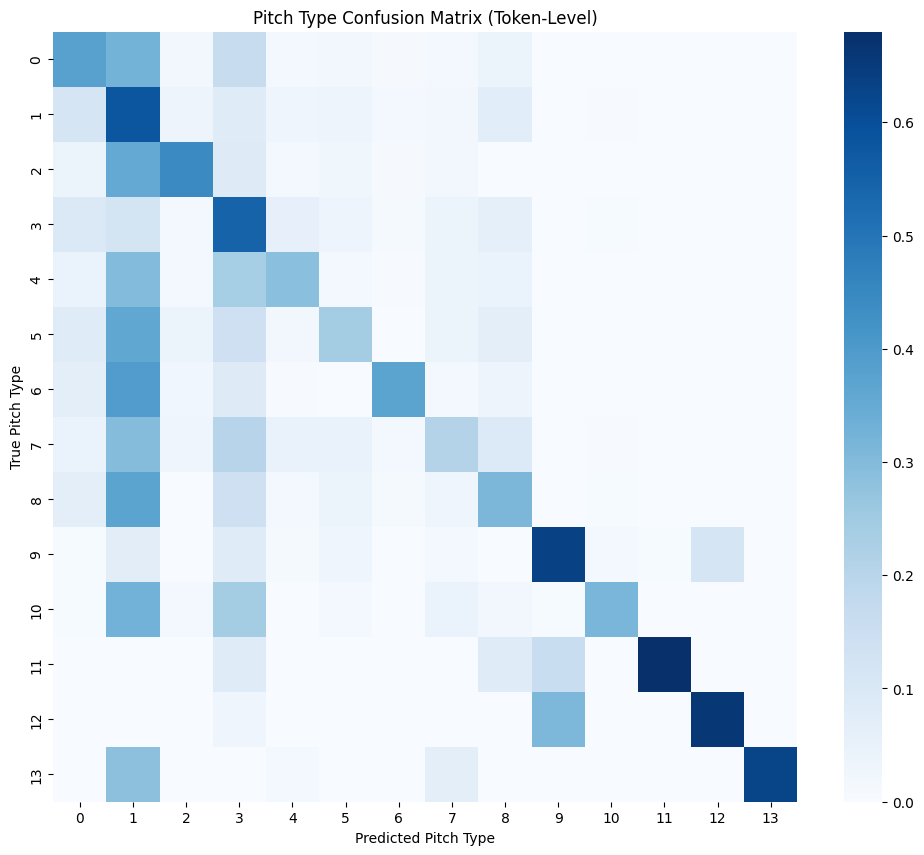

In [20]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

model.eval()
all_preds = [] 
all_true = []

with torch.no_grad():
    for x_cat, x_num, y in test_loader:
        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y = y.to(device)
        logits = model(x_cat, x_num)        # (B, L, C)
        preds  = logits.argmax(dim=-1)      # (B, L)

        mask = (y != PAD_ID)

        # mask == 1 for valid tokens, 0 for PAD
        valid = mask.bool()

        all_preds.append(preds[valid].cpu().numpy())
        all_true.append(y[valid].cpu().numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_true)


cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    fmt="d"
)
plt.xlabel("Predicted Pitch Type")
plt.ylabel("True Pitch Type")
plt.title("Pitch Type Confusion Matrix (Token-Level)")
plt.show()


In [21]:
from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred, target_names=list(id_to_pitch.values()))
print(report)

              precision    recall  f1-score   support

          SL       0.43      0.38      0.40     15639
          FF       0.48      0.58      0.52     33178
          FS       0.41      0.44      0.43      4024
          SI       0.41      0.55      0.47     15255
          ST       0.42      0.29      0.34      7526
          CU       0.36      0.24      0.29      7245
          KC       0.37      0.37      0.37      1837
          FC       0.38      0.21      0.27      7753
          CH       0.40      0.31      0.35     12119
       OTHER       0.61      0.64      0.62       162
          SV       0.28      0.31      0.30       509
          KN       0.71      0.68      0.69        25
          EP       0.74      0.66      0.70        97
          FO       0.37      0.63      0.47        70

    accuracy                           0.43    105439
   macro avg       0.46      0.45      0.44    105439
weighted avg       0.43      0.43      0.42    105439

